In [ ]:

!pip install -q tqdm

In [ ]:
!pip install ptflops

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
#  All necessary imports
import os
import cv2
import numpy as np
import random
from concurrent.futures import ThreadPoolExecutor, as_completed
from google.colab import drive
from tqdm import tqdm

In [ ]:
#  Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  Dataset folder paths (adjust these paths as needed)
dataset_paths = [

    "/content/drive/MyDrive//dataset2/garbage_classification",

]

In [ ]:
#  Output merged folder
output_folder = "/content/output"

In [ ]:

#  Collect all unique class folders from all datasets
all_classes = set()
for dataset_path in dataset_paths:
    for class_folder in os.listdir(dataset_path):
        full_class_path = os.path.join(dataset_path, class_folder)
        if os.path.isdir(full_class_path):
            all_classes.add(class_folder)

In [ ]:
#  Create class-wise subfolders in the output directory
for class_name in all_classes:
    os.makedirs(os.path.join(output_folder, class_name), exist_ok=True)

In [ ]:
#  Image processing parameters
img_size = (224, 224)

In [ ]:
#  Function to apply preprocessing and augmentation
def process_image(img_path, img_name, class_name):
    if '.ipynb_checkpoints' in img_name:
        return

    img = cv2.imread(img_path)
    if img is None:
        return

    h, w, _ = img.shape
    crop_size = min(h, w)
    start_x = (w - crop_size) // 2
    start_y = (h - crop_size) // 2
    img_cropped = img[start_y:start_y+crop_size, start_x:start_x+crop_size]
    img_resized = cv2.resize(img_cropped, img_size)
    img_blurred = cv2.GaussianBlur(img_resized, (5, 5), 0)
    img_gray = cv2.cvtColor(img_blurred, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_enhanced = clahe.apply(img_gray)
    img_normalized = cv2.normalize(img_enhanced, None, 0, 255, cv2.NORM_MINMAX)
    img_final = cv2.cvtColor(img_normalized, cv2.COLOR_GRAY2BGR)

    # Data Augmentation
    augmented_images = [img_final]
    augmented_images.append(cv2.flip(img_final, 1))  # Horizontal flip

    angle = random.choice([-15, 15])
    M = cv2.getRotationMatrix2D((img_size[0]//2, img_size[1]//2), angle, 1)
    augmented_images.append(cv2.warpAffine(img_final, M, img_size))

    brightness_factor = random.uniform(0.7, 1.3)
    img_bright = np.clip(img_final * brightness_factor, 0, 255).astype(np.uint8)
    augmented_images.append(img_bright)

    class_output_folder = os.path.join(output_folder, class_name)

    for i, aug_img in enumerate(augmented_images):
        aug_img_name = f"{os.path.splitext(img_name)[0]}_aug{i}.png"
        cv2.imwrite(os.path.join(class_output_folder, aug_img_name), aug_img)

In [ ]:
#  Process all images in all datasets with progress bar
def preprocess_and_save_images():
    futures = []
    with ThreadPoolExecutor(max_workers=4) as executor:
        for dataset_path in dataset_paths:
            for class_name in os.listdir(dataset_path):
                class_input_path = os.path.join(dataset_path, class_name)
                if not os.path.isdir(class_input_path):
                    continue

                for img_name in os.listdir(class_input_path):
                    img_path = os.path.join(class_input_path, img_name)
                    if not os.path.isfile(img_path):
                        continue
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
                        futures.append(executor.submit(process_image, img_path, img_name, class_name))

        # Progress bar with tqdm while images are being processed
        for _ in tqdm(as_completed(futures), total=len(futures), desc="Processing images"):
            pass

#  Start the preprocessing pipeline
preprocess_and_save_images()
#  Done
print(" Merged preprocessing complete! Images saved in:", output_folder)

Processing images: 100%|██████████| 15546/15546 [21:44<00:00, 11.92it/s]


 Merged preprocessing complete! Images saved in: /content/output


In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [ ]:
import os
from PIL import Image
from torch.utils.data import Dataset

class GarbageDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = sorted(os.listdir(root_dir))
        self.image_paths = []
        self.labels = []

        for idx, class_name in enumerate(self.classes):
            class_folder = os.path.join(root_dir, class_name)
            for img_name in os.listdir(class_folder):
                if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.image_paths.append(os.path.join(class_folder, img_name))
                    self.labels.append(idx)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, random_split

data_path = "/content/output"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = GarbageDataset(root_dir=data_path, transform=transform)
print(f"Total images found: {len(dataset)}")

# 📌 60:20:20 split (as per your paper)
train_size = int(0.6 * len(dataset))
val_size   = int(0.2 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
valid_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

test_loader  = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)



Total images found: 62184


In [ ]:
from torch.optim import Adam

In [ ]:
# Model, Loss, Optimizer
model = SimpleRepVGG(num_classes=14).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=0.001)

In [ ]:
model = SimpleRepVGG(num_classes=14).to(device)
ema = EMA(model)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


In [ ]:
import numpy as np
import torch



In [ ]:
import torch
import torch.nn as nn

class MSCA(nn.Module):
    def __init__(self, channels):
        super(MSCA, self).__init__()
        # 5x5 depthwise conv
        self.conv5 = nn.Conv2d(channels, channels, kernel_size=5, padding=2, groups=channels)

        # 7x1 and 1x7 conv pair
        self.conv7_1 = nn.Conv2d(channels, channels, kernel_size=(7, 1), padding=(3, 0), groups=channels)
        self.conv1_7 = nn.Conv2d(channels, channels, kernel_size=(1, 7), padding=(0, 3), groups=channels)

        # 11x1 and 1x11 conv pair
        self.conv11_1 = nn.Conv2d(channels, channels, kernel_size=(11, 1), padding=(5, 0), groups=channels)
        self.conv1_11 = nn.Conv2d(channels, channels, kernel_size=(1, 11), padding=(0, 5), groups=channels)

        # 21x1 and 1x21 conv pair
        self.conv21_1 = nn.Conv2d(channels, channels, kernel_size=(21, 1), padding=(10, 0), groups=channels)
        self.conv1_21 = nn.Conv2d(channels, channels, kernel_size=(1, 21), padding=(0, 10), groups=channels)

        # 1x1 fusion conv
        self.conv1x1 = nn.Conv2d(channels * 5, channels, kernel_size=1)

        # Activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out5 = self.conv5(x)

        out7 = self.conv7_1(x)
        out7 = self.conv1_7(out7)

        out11 = self.conv11_1(x)
        out11 = self.conv1_11(out11)

        out21 = self.conv21_1(x)
        out21 = self.conv1_21(out21)

        # Skip connection (original input)
        skip = x

        # Concatenate all branches
        out = torch.cat([skip, out5, out7, out11, out21], dim=1)

        # 1x1 conv fusion
        out = self.conv1x1(out)

        # Apply sigmoid to get attention map
        attention = self.sigmoid(out)

        # Element-wise multiply attention map with input feature map
        return x * attention


In [ ]:
import torch
import torch.nn as nn

class RepVGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(RepVGGBlock, self).__init__()

        # 3x3 conv branch
        self.rbr_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        # 1x1 conv branch
        self.rbr_1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0, bias=False),
            nn.BatchNorm2d(out_channels)
        )

        # Identity branch (only if input and output dims match and stride=1)
        self.use_identity = (in_channels == out_channels and stride == 1)
        if self.use_identity:
            self.rbr_identity = nn.BatchNorm2d(in_channels)
        else:
            self.rbr_identity = None

        # Activation
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.rbr_conv(x) + self.rbr_1x1(x)
        if self.use_identity:
            out += self.rbr_identity(x)
        return self.relu(out)


In [ ]:
import torch
import torch.nn as nn

class SimpleRepVGG_MEM(nn.Module):
    def __init__(self, num_classes=14):
        super(SimpleRepVGG_MEM, self).__init__()

        # Stage 0
        self.stage0 = nn.Sequential(
            nn.Conv2d(3, 64, 3, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        # Stage 1 (2 blocks)
        self.stage1 = nn.Sequential(
            RepVGGBlock(64, 128, stride=2),
            RepVGGBlock(128, 128, stride=1)
        )

        # Stage 2 (4 blocks)
        self.stage2 = nn.Sequential(
            RepVGGBlock(128, 256, stride=2),
            RepVGGBlock(256, 256, stride=1),
            RepVGGBlock(256, 256, stride=1),
            RepVGGBlock(256, 256, stride=1)
        )

        # Stage 3 (14 blocks + MSCA)
        stage3_blocks = [RepVGGBlock(256, 512, stride=2)]
        stage3_blocks += [RepVGGBlock(512, 512, stride=1) for _ in range(13)]
        stage3_blocks.append(MSCA(512))
        self.stage3 = nn.Sequential(*stage3_blocks)

        # Stage 4 (1 block + MSCA)
        self.stage4 = nn.Sequential(
            RepVGGBlock(512, 512, stride=2),
            MSCA(512)
        )

        # Classifier
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.stage0(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x


In [ ]:
import torch

class EMA:
    def __init__(self, model, decay=0.999):
        self.model = model
        self.decay = decay
        self.shadow = {}
        self.backup = {}

        # Register initial parameters to shadow
        self.register()

    def register(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.shadow[name] = param.data.detach().clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                assert name in self.shadow
                new_avg = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]
                self.shadow[name] = new_avg.detach().clone()

    def apply_shadow(self):
        # Backup current model parameters before applying EMA weights
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                self.backup[name] = param.data.detach().clone()
                param.data = self.shadow[name].to(param.device)

    def restore(self):
        # Restore original parameters after validation/testing
        for name, param in self.model.named_parameters():
            if param.requires_grad:
                param.data = self.backup[name].to(param.device)
        self.backup = {}


In [ ]:
import numpy as np
import torch

def mixup_data(x, y, alpha=0.4):
    '''Mixup data augmentation. Returns mixed inputs, pairs of targets, and lambda'''
    if alpha > 0.0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0

    batch_size = x.size(0)
    if batch_size == 1:
        # Edge case: cannot permute a single sample — skip mixup
        return x, y, y, 1.0

    index = torch.randperm(batch_size).to(x.device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam


In [ ]:
from tqdm import tqdm
import torch.nn.functional as F

# Model, optimizer, EMA
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleRepVGG_MEM(num_classes=14).to(device)
ema = EMA(model)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
pip install torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 20.2 MB/s eta 0:00:00


In [ ]:
from torchmetrics.classification import MulticlassF1Score, MulticlassPrecision, MulticlassRecall

def evaluate_model(model, loader, criterion, device, num_classes=14):
    model.eval()
    running_loss = 0.0
    total_correct = 0
    total_samples = 0

    f1_metric = MulticlassF1Score(num_classes=num_classes, average='macro').to(device)
    prec_metric = MulticlassPrecision(num_classes=num_classes, average='macro').to(device)
    recall_metric = MulticlassRecall(num_classes=num_classes, average='macro').to(device)

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            f1_metric.update(preds, labels)
            prec_metric.update(preds, labels)
            recall_metric.update(preds, labels)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * total_correct / total_samples
    f1 = f1_metric.compute().item()
    precision = prec_metric.compute().item()
    recall = recall_metric.compute().item()

    return avg_loss, accuracy, precision, recall, f1, all_labels, all_preds


In [ ]:
def validate(model, valid_loader, criterion, device):
    return evaluate_model(model, valid_loader, criterion, device)


In [ ]:
def evaluate(model, test_loader, criterion, device=None):
    return evaluate_model(model, test_loader, criterion, device)


In [ ]:
import time
epochs = 25

# 📊 Trackers
train_losses, train_accuracies = [], []
val_losses, val_accuracies, val_precisions, val_recalls, val_f1s = [], [], [], [], []
test_accuracies, test_precisions, test_recalls, test_f1s = [], [], [], []
best_val_acc = 0.0

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    loop = tqdm(train_loader, desc=f'Epoch [{epoch+1}/{epochs}]', leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        # 🔄 Mixup augmentation
        images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.4)

        optimizer.zero_grad()
        outputs = model(images)

        # 🔍 Mixup loss
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
        loss.backward()
        optimizer.step()

        # 🔄 EMA update
        ema.update()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)

        loop.set_postfix(loss=loss.item())

    # 📊 Epoch train stats
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100.0 * correct_preds / total_samples

    # 📈 Apply EMA before validation/test
    ema.apply_shadow()

    val_loss, val_acc, val_prec, val_recall, val_f1 = validate(model, valid_loader, criterion, device)
    test_loss, test_acc, test_prec, test_recall, test_f1 = evaluate(model, test_loader, criterion, device)

    # 🔙 Restore model for next epoch training
    ema.restore()

    # 📊 Record metrics
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_precisions.append(val_prec)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)
    test_accuracies.append(test_acc)
    test_precisions.append(test_prec)
    test_recalls.append(test_recall)
    test_f1s.append(test_f1)

    # 📊 Epoch Summary
    print(f"\n✅ Epoch {epoch+1}/{epochs}, "
          f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.2f}%, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, F1: {val_f1:.2f}, "
          f"Test Acc: {test_acc:.2f}%, Test F1: {test_f1:.2f}")

    # 💾 Save best checkpoint
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"/content/drive/MyDrive/repvgg_mem_best_epoch{epoch+1}.pth")
        print(f"✅ New best model saved at epoch {epoch+1}, Val Acc: {val_acc:.2f}%")

    end_time = time.time()
    print(f"⏰ Epoch {epoch+1} took {(end_time - start_time) / 60:.2f} minutes")

# ✅ Final EMA weights applied for final test/evaluation/report
ema.apply_shadow()
model.eval()
print("✅ RepVGG-MEM (Mixup + EMA + MSCA) training complete.")


✅ Epoch 1/25, Train Loss: 1.7337, Train Acc: 36.53%, Val Loss: 2.3939, Val Acc: 34.69%, F1: 0.04, Test Acc: 34.64%, Test F1: 0.04
✅ New best model saved at epoch 1, Val Acc: 34.69%
⏰ Epoch 1 took 9.21 minutes



✅ Epoch 2/25, Train Loss: 1.4066, Train Acc: 43.10%, Val Loss: 2.3741, Val Acc: 22.02%, F1: 0.10, Test Acc: 21.97%, Test F1: 0.10
⏰ Epoch 2 took 9.20 minutes



✅ Epoch 3/25, Train Loss: 1.1933, Train Acc: 46.33%, Val Loss: 1.8479, Val Acc: 41.35%, F1: 0.17, Test Acc: 41.32%, Test F1: 0.16
✅ New best model saved at epoch 3, Val Acc: 41.35%
⏰ Epoch 3 took 9.22 minutes



✅ Epoch 4/25, Train Loss: 1.0605, Train Acc: 50.17%, Val Loss: 1.5255, Val Acc: 52.37%, F1: 0.34, Test Acc: 52.40%, Test F1: 0.33
✅ New best model saved at epoch 4, Val Acc: 52.37%
⏰ Epoch 4 took 9.17 minutes



✅ Epoch 5/25, Train Loss: 0.9395, Train Acc: 51.93%, Val Loss: 0.8218, Val Acc: 77.08%, F1: 0.68, Test Acc: 77.60%, Test F1: 0.69
✅ New best model saved at epoch 5, Val Acc: 77.08%
⏰ Epoch 5 took 9.16 minutes


...


✅ Epoch 19/25, Train Loss: 0.6300, Train Acc: 58.98%, Val Loss: 0.4800, Val Acc: 88.07%, F1: 0.84, Test Acc: 88.00%, Test F1: 0.83
⏰ Epoch 19 took 9.05 minutes



✅ Epoch 20/25, Train Loss: 0.5921, Train Acc: 58.20%, Val Loss: 1.1551, Val Acc: 71.23%, F1: 0.64, Test Acc: 72.29%, Test F1: 0.66
⏰ Epoch 20 took 9.05 minutes



✅ Epoch 21/25, Train Loss: 0.5968, Train Acc: 58.17%, Val Loss: 0.3919, Val Acc: 89.72%, F1: 0.86, Test Acc: 90.09%, Test F1: 0.86
⏰ Epoch 21 took 9.07 minutes



✅ Epoch 22/25, Train Loss: 0.5968, Train Acc: 57.93%, Val Loss: 0.3471, Val Acc: 91.43%, F1: 0.88, Test Acc: 91.58%, Test F1: 0.88
⏰ Epoch 22 took 9.08 minutes


KeyboardInterrupt: 

In [ ]:
# Save final trained model weights
torch.save(model.state_dict(), "/content/drive/MyDrive/repvgg_MEM_final.pth")
print("✅ RepVGG-MEM final model saved!")


✅ RepVGG-MEM final model saved!


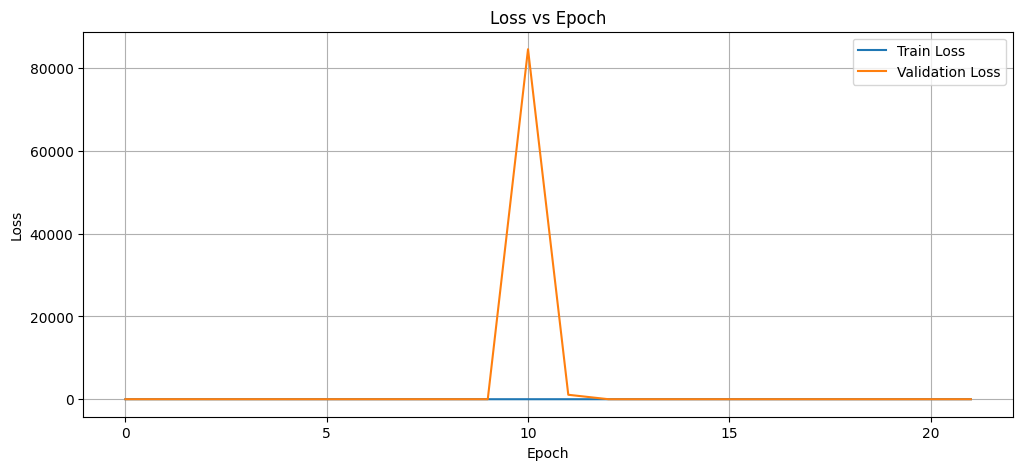

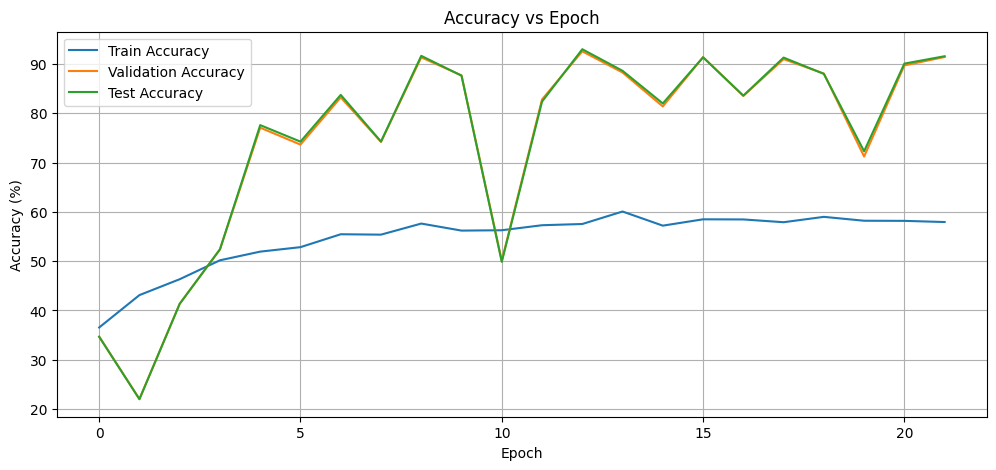

In [ ]:
import matplotlib.pyplot as plt

# 📉 Loss graph
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()
plt.show()

# 📈 Accuracy graph
plt.figure(figsize=(12, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

# Evaluate on test set again for final results
test_loss, test_acc, precision, recall, f1, test_labels, test_preds = evaluate(model, test_loader, criterion, device)



# 📃 Classification Report
target_names = dataset.classes
report = classification_report(test_labels, test_preds, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).T

# Display neatly
print(report_df)


              precision    recall  f1-score       support
battery        0.809789  0.952880  0.875526    764.000000
biological     0.885457  0.910053  0.897586    756.000000
brown-glass    0.831740  0.864811  0.847953    503.000000
cardboard      0.877747  0.900000  0.888734    710.000000
clothes        0.977014  0.976561  0.976787   4309.000000
green-glass    0.871605  0.703187  0.778390    502.000000
metal          0.842105  0.853333  0.847682    600.000000
paper          0.877934  0.923457  0.900120    810.000000
plastic        0.879389  0.837209  0.857781    688.000000
shoes          0.943828  0.919796  0.931657   1571.000000
trash          0.954386  0.917369  0.935512    593.000000
white-glass    0.922813  0.851266  0.885597    632.000000
accuracy       0.917672  0.917672  0.917672      0.917672
macro avg      0.889484  0.884160  0.885277  12438.000000
weighted avg   0.918997  0.917672  0.917404  12438.000000


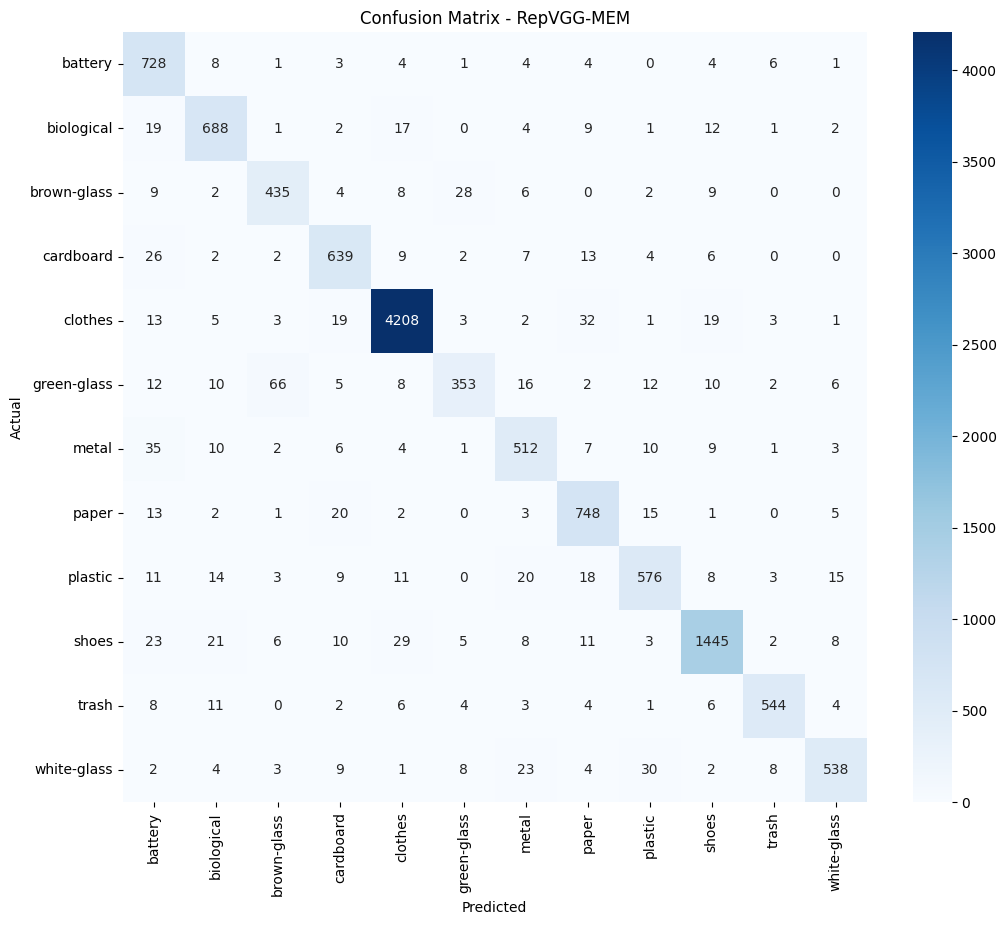

In [ ]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title("Confusion Matrix - RepVGG-MEM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
from ptflops import get_model_complexity_info

macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)
print(f"FLOPs (MACs): {macs}")
print(f"Params: {params}")


FLOPs (MACs): 10.02 GMac
Params: 43.35 M


In [ ]:

print(f"\n📊 Final Results - RepVGG-MEM")
print(f"Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"FLOPs (MACs): {macs}")
print(f"Parameters: {params}")



📊 Final Results - RepVGG-MEM
Train Accuracy: 57.93%
Validation Accuracy: 91.43%
Test Accuracy: 91.77%
FLOPs (MACs): 10.02 GMac
Parameters: 43.35 M


In [ ]:
!pip install scikit-learn --quiet


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Final Evaluation with EMA weights
ema.apply_shadow()
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:  # or test_loader if you have one
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Accuracy
final_acc = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n✅ Final Accuracy: {final_acc:.2f}%")







✅ Final Accuracy: 91.73%


In [ ]:
print(f"\n📊 Final Results - RepVGG-MEM")
print(f"Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"FLOPs (MACs): {macs}")
print(f"Parameters: {params}")


📊 Final Results - RepVGG-MEM
Train Accuracy: 57.93%
Validation Accuracy: 91.43%
Test Accuracy: 91.77%
FLOPs (MACs): 10.02 GMac
Parameters: 43.35 M


In [ ]:
class RepVGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(RepVGGBlock, self).__init__()
        self.rbr_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.rbr_1x1 = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 1, stride, 0, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        self.msca = MSCA(out_channels)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.rbr_conv(x) + self.rbr_1x1(x)
        out = self.msca(out)
        return self.relu(out)



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import numpy as np

# Final Evaluation with EMA weights
ema.apply_shadow()
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in valid_loader:  # or test_loader if you have one
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Final Accuracy
final_acc = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n✅ Final Accuracy: {final_acc:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_dataset.classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\n📊 Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_dataset.classes))


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/repvgg_MEM_final.pth")

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleRepVGG_MEM(num_classes=14).to(device)
model.load_state_dict(torch.load("/content/drive/MyDrive/repvgg_MEM_final.pth", map_location=device))
model.eval()


SimpleRepVGG_MEM(
  (stage0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (stage1): Sequential(
    (0): RepVGGBlock(
      (rbr_conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (rbr_1x1): Sequential(
        (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU()
    )
    (1): RepVGGBlock(
      (rbr_conv): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (rbr_1

In [ ]:
ema = EMA(model, decay=0.999)


In [ ]:
# Required imports if reloading
import torch.nn as nn
import torch.optim as optim

# Recreate optimizer, loss, EMA
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
ema = EMA(model, decay=0.999)  # Reinitialize with the restored model


REPVGG_MEM+L1-norm

In [ ]:
def l1_prune_conv_layer(conv_layer, amount=0.3):
    weight = conv_layer.weight.data.abs().sum(dim=(1, 2, 3))
    num_prune = int(amount * conv_layer.out_channels)
    if num_prune == 0:
        return
    prune_indices = weight.argsort()[:num_prune]
    conv_layer.weight.data[prune_indices] = 0.0
    if conv_layer.bias is not None:
        conv_layer.bias.data[prune_indices] = 0.0

# Apply pruning to Stage 3 and Stage 4
for module in model.stage3.modules():
    if isinstance(module, nn.Conv2d):
        l1_prune_conv_layer(module, amount=0.3)

for module in model.stage4.modules():
    if isinstance(module, nn.Conv2d):
        l1_prune_conv_layer(module, amount=0.3)
print("✅ L1-Norm pruning applied to Stage 3 & 4.")



✅ L1-Norm pruning applied to Stage 3 & 4.


In [ ]:
import matplotlib.pyplot as plt
from tqdm import tqdm

fine_tune_epochs = 15
train_accuracies, val_accuracies, test_accuracies = [], [], []
val_precisions, val_recalls, val_f1s = [], [], []
test_precisions, test_recalls, test_f1s = [], [], []

for epoch in range(fine_tune_epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_samples = 0

    loop = tqdm(train_loader, desc=f"[Fine-tune Epoch {epoch+1}/{fine_tune_epochs}]", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)
        images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=0.4)

        optimizer.zero_grad()
        outputs = model(images)
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
        loss.backward()
        optimizer.step()
        ema.update()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_preds += (preds == labels).sum().item()
        total_samples += labels.size(0)
        loop.set_postfix(loss=loss.item())

    train_acc = 100.0 * correct_preds / total_samples
    train_accuracies.append(train_acc)

    # 📊 Validation & Test using EMA shadow weights
    ema.apply_shadow()
    val_loss, val_acc, val_prec, val_recall, val_f1, val_labels, val_preds = validate(model, valid_loader, criterion, device)
    test_loss, test_acc, test_prec, test_recall, test_f1, test_labels, test_preds = evaluate(model, test_loader, criterion, device)
    ema.restore()

    val_accuracies.append(val_acc)
    val_precisions.append(val_prec)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    test_accuracies.append(test_acc)
    test_precisions.append(test_prec)
    test_recalls.append(test_recall)
    test_f1s.append(test_f1)

    print(f"✅ Fine-tune Epoch {epoch+1}, "
          f"Train Acc: {train_acc:.2f}%, "
          f"Val Acc: {val_acc:.2f}%, Precision: {val_prec:.2f}, Recall: {val_recall:.2f}, F1: {val_f1:.2f}, "
          f"Test Acc: {test_acc:.2f}%, Precision: {test_prec:.2f}, Recall: {test_recall:.2f}, F1: {test_f1:.2f}")


✅ Fine-tune Epoch 1, Train Acc: 55.50%, Val Acc: 87.29%, Precision: 0.86, Recall: 0.89, F1: 0.87, Test Acc: 87.23%, Precision: 0.86, Recall: 0.89, F1: 0.86


✅ Fine-tune Epoch 2, Train Acc: 58.01%, Val Acc: 95.07%, Precision: 0.93, Recall: 0.94, F1: 0.93, Test Acc: 95.16%, Precision: 0.93, Recall: 0.94, F1: 0.93


✅ Fine-tune Epoch 3, Train Acc: 56.04%, Val Acc: 95.26%, Precision: 0.94, Recall: 0.93, F1: 0.93, Test Acc: 95.01%, Precision: 0.94, Recall: 0.93, F1: 0.93


✅ Fine-tune Epoch 4, Train Acc: 58.38%, Val Acc: 97.04%, Precision: 0.96, Recall: 0.96, F1: 0.96, Test Acc: 97.00%, Precision: 0.96, Recall: 0.96, F1: 0.96


✅ Fine-tune Epoch 5, Train Acc: 58.45%, Val Acc: 94.23%, Precision: 0.92, Recall: 0.92, F1: 0.92, Test Acc: 94.31%, Precision: 0.92, Recall: 0.92, F1: 0.92


...

✅ Fine-tune Epoch 7, Train Acc: 58.18%, Val Acc: 89.79%, Precision: 0.88, Recall: 0.91, F1: 0.89, Test Acc: 90.35%, Precision: 0.88, Recall: 0.92, F1: 0.90


✅ Fine-tune Epoch 8, Train Acc: 58.36%, Val Acc: 91.85%, Precision: 0.89, Recall: 0.92, F1: 0.90, Test Acc: 92.14%, Precision: 0.90, Recall: 0.92, F1: 0.91


✅ Fine-tune Epoch 9, Train Acc: 55.09%, Val Acc: 93.24%, Precision: 0.91, Recall: 0.91, F1: 0.91, Test Acc: 92.76%, Precision: 0.90, Recall: 0.91, F1: 0.90


✅ Fine-tune Epoch 10, Train Acc: 56.62%, Val Acc: 94.89%, Precision: 0.93, Recall: 0.93, F1: 0.93, Test Acc: 94.88%, Precision: 0.93, Recall: 0.93, F1: 0.93


KeyboardInterrupt: 

In [ ]:
ema.apply_shadow()
model.eval()
torch.save(model.state_dict(), "/content/drive/MyDrive/repvgg_mem_pruned_finetuned.pth")
print("✅ Final fine-tuned + pruned model saved.")


✅ Final fine-tuned + pruned model saved.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import numpy as np

def plot_confusion_matrix(model, loader, class_names, device):
    model.eval()
    ema.apply_shadow()  # Apply EMA weights if used

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    ema.restore()  # Restore model weights after EMA


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import pandas as pd

# Evaluate on test set again for final results
test_loss, test_acc, precision, recall, f1, test_labels, test_preds = evaluate(model, test_loader, criterion, device)



# 📃 Classification Report
target_names = dataset.classes
report = classification_report(test_labels, test_preds, target_names=target_names, output_dict=True)
report_df = pd.DataFrame(report).T

# Display neatly
print(report_df)

              precision    recall  f1-score       support
battery        0.756531  0.986376  0.856298    734.000000
biological     0.947368  0.977483  0.962190    755.000000
brown-glass    0.876173  0.924752  0.899807    505.000000
cardboard      0.975540  0.948252  0.961702    715.000000
clothes        0.991357  0.967432  0.979248   4268.000000
green-glass    0.920000  0.848544  0.882828    515.000000
metal          0.880597  0.956240  0.916861    617.000000
paper          0.970186  0.943237  0.956522    828.000000
plastic        0.983974  0.884726  0.931715    694.000000
shoes          0.972205  0.961274  0.966709   1601.000000
trash          0.980732  0.953184  0.966762    534.000000
white-glass    0.976303  0.919643  0.947126    672.000000
accuracy       0.950635  0.950635  0.950635      0.950635
macro avg      0.935914  0.939262  0.935647  12438.000000
weighted avg   0.955238  0.950635  0.951585  12438.000000


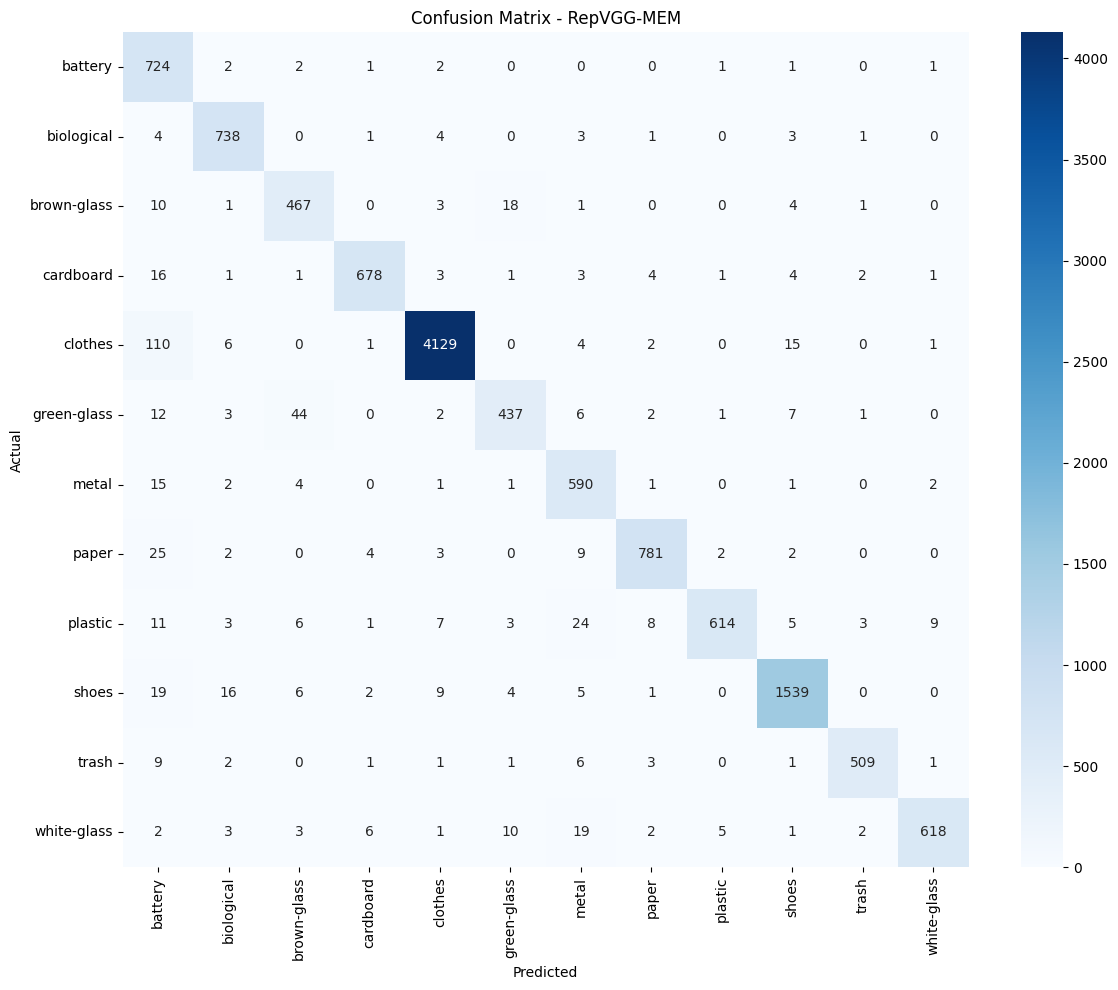

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ✅ Check that these are defined
# test_labels = list of ground truth labels from test set
# test_preds = list of predicted labels from model
# target_names = list of class names (length must match number of classes)

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)

plt.title("Confusion Matrix - RepVGG-MEM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Apply EMA before final evaluation
ema.apply_shadow()
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:  # you can switch to valid_loader if needed
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ✅ Final Accuracy
final_acc = 100.0 * np.sum(np.array(all_preds) == np.array(all_labels)) / len(all_labels)
print(f"\n✅ Final Test Accuracy: {final_acc:.2f}%")


✅ Final Test Accuracy: 95.06%


In [ ]:
# ✅ Classification Report
print("\n📊 Classification Report:")
print(classification_report(all_labels, all_preds, digits=2))


📊 Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.99      0.86       734
           1       0.95      0.98      0.96       755
           2       0.88      0.92      0.90       505
           3       0.98      0.95      0.96       715
           4       0.99      0.97      0.98      4268
           5       0.92      0.85      0.88       515
           6       0.88      0.96      0.92       617
           7       0.97      0.94      0.96       828
           8       0.98      0.88      0.93       694
           9       0.97      0.96      0.97      1601
          10       0.98      0.95      0.97       534
          11       0.98      0.92      0.95       672

    accuracy                           0.95     12438
   macro avg       0.94      0.94      0.94     12438
weighted avg       0.96      0.95      0.95     12438



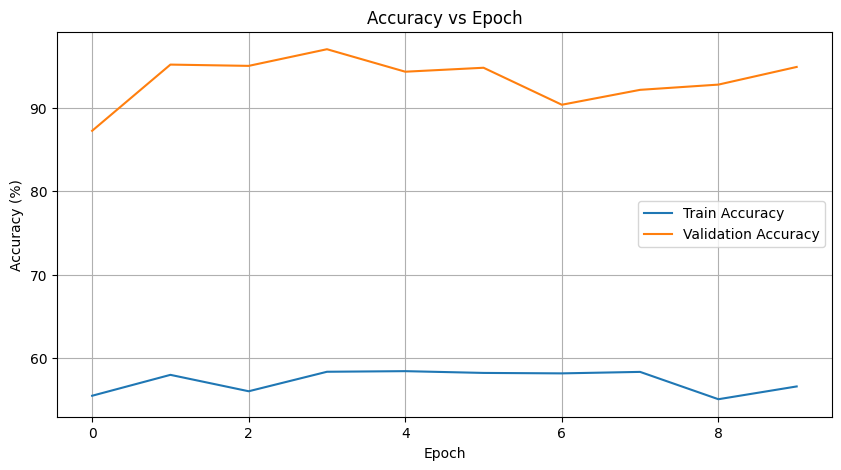

In [ ]:
import matplotlib.pyplot as plt



# Plot Accuracy vs Epoch
plt.figure(figsize=(10, 5))
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(test_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy vs Epoch')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from ptflops import get_model_complexity_info

macs, params = get_model_complexity_info(model, (3, 224, 224), as_strings=True, print_per_layer_stat=False)
print(f"FLOPs (MACs): {macs}")
print(f"Params: {params}")



FLOPs (MACs): 10.02 GMac
Params: 43.35 M


In [ ]:
print(f"\n📊 Final Results - RepVGG-MEM")
print(f"Train Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"FLOPs (MACs): {macs}")
print(f"Parameters: {params}")


📊 Final Results - RepVGG-MEM
Train Accuracy: 56.62%
Validation Accuracy: 94.89%
Test Accuracy: 95.06%
FLOPs (MACs): 10.02 GMac
Parameters: 43.35 M
